<div style="font-family:'Segoe UI',Roboto,Helvetica,Arial,sans-serif;max-width:900px;margin:0 auto;border-radius:16px;overflow:hidden;box-shadow:0 4px 20px rgba(0,0,0,0.12);border:1px solid #e2e2e2;">

<div style="background:linear-gradient(135deg,#002855 0%,#004b8d 55%,#0077c8 100%);padding:28px 20px 22px 20px;text-align:center;">
<img src="./img/ITESOLogo.png" alt="ITESO" width="260" style="margin-bottom:10px;">
<div style="color:#ffffff;font-size:15px;font-weight:600;letter-spacing:0.5px;text-transform:uppercase;opacity:0.9;">
Departamento de Electrónica, Sistemas e Informática
</div>
</div>

<div style="background-color:#ffffff;padding:26px 30px 30px 30px;text-align:center;">

<div style="color:#002855;font-size:26px;font-weight:800;margin-bottom:6px;">
Big Data Analysis
</div>

<div style="display:inline-block;background-color:#eaf4fb;color:#0077c8;font-size:13px;font-weight:700;padding:4px 14px;border-radius:20px;letter-spacing:0.5px;margin-bottom:22px;">
Autumn 2026
</div>


<hr style="border:none;border-top:2px solid #f0f0f0;margin:0 0 22px 0;">

<div style="background-color:#f7fafd;border-left:5px solid #0077c8;border-radius:8px;padding:14px 18px;text-align:left;margin-bottom:18px;">
<div style="font-size:12px;color:#7a7a7a;font-weight:600;text-transform:uppercase;letter-spacing:0.5px;margin-bottom:4px;">
Session 07
</div>
<div style="font-size:19px;color:#002855;font-weight:700;">
Map-Reduce with RDDs
</div>
</div>

<div style="font-size:14px;color:#444;margin-top:20px;">
<span style="font-weight:700;color:#002855;">Profesor:</span> Pablo Camarillo Ramírez
</div>

</div>
</div>

In [1]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
            .appName("Map-Reduce") \
            .master("local[*]") \
            .config("spark.ui.port", "4040") \
            .getOrCreate()

sc = spark.sparkContext

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/10 02:37:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
numbers = [1, 55, 64, 34, 65]
rdd = sc.parallelize(numbers)
squares = rdd.map(lambda x: x ** 2)
print(squares.__class__)
result = squares.collect()
print(result.__class__)

<class 'pyspark.core.rdd.PipelinedRDD'>
<class 'list'>


In [6]:
r = ('a', 1) + ('a', 5)
r

('a', 1, 'a', 5)

In [7]:
data = [
('apple', 1),
('banana', 2),
('apple', 3),
('orange', 4),
('banana', 1),
('orange', 2)
]
print(data)

rdd_data = sc.parallelize(data)
result = rdd_data.reduceByKey(lambda x, y: x + y)
r = result.collect()
r

[('apple', 1), ('banana', 2), ('apple', 3), ('orange', 4), ('banana', 1), ('orange', 2)]


[('banana', 3), ('apple', 4), ('orange', 6)]

In [8]:
grpupped_rdd = rdd_data.groupByKey()
group = grpupped_rdd.collect()
group


[('banana', <pyspark.resultiterable.ResultIterable at 0xffff40c634c0>),
 ('apple', <pyspark.resultiterable.ResultIterable at 0xffff40c632b0>),
 ('orange', <pyspark.resultiterable.ResultIterable at 0xffff40c626b0>)]

In [9]:
for k,v in group:
    print(f"[{k}] -> {list(v)}")

[banana] -> [2, 1]
[apple] -> [1, 3]
[orange] -> [4, 2]


In [10]:
words = ["apple", "banana", "apple", "orange",
"banana", "apple", "orange", "orange"]
words_rdd = sc.parallelize(words)
print(words_rdd.collect())
counter = words_rdd.countByValue()
counter

['apple', 'banana', 'apple', 'orange', 'banana', 'apple', 'orange', 'orange']


defaultdict(int, {'apple': 3, 'banana': 2, 'orange': 3})

In [11]:
numbers = [i for i in range(100)]

In [13]:
numbers_rdd = sc.parallelize(numbers)
filtered = numbers_rdd.filter(lambda x: x % 5 == 0)
res_filter = filtered.collect()
res_filter


[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]

In [ ]:
print(res_filter.__class__)

In [ ]:
res_filter

In [14]:
!apt-get update
!apt-get -y install tesseract-ocr
!pip install pytesseract pillow opencv-python

Hit:1 http://ports.ubuntu.com/ubuntu-ports jammy InRelease
Get:2 http://ports.ubuntu.com/ubuntu-ports jammy-updates InRelease [128 kB]
Hit:3 http://ports.ubuntu.com/ubuntu-ports jammy-backports InRelease
Hit:4 http://ports.ubuntu.com/ubuntu-ports jammy-security InRelease
Fetched 128 kB in 1s (130 kB/s)
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 60 not upgraded.


In [15]:
from PIL import Image
import pytesseract

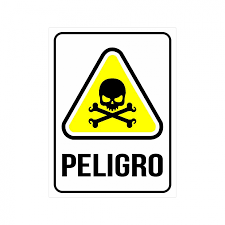

In [17]:
img = Image.open("/opt/spark/work-dir/notebooks/img/text1.png")
img

In [18]:
text = pytesseract.image_to_string(img)
text

'(a\n\nPELIGRO\n\n   \n\x0c'

In [19]:
def extract_text(filename):
    img = Image.open(filename)
    return pytesseract.image_to_string(img)

In [20]:
files = ["/opt/spark/work-dir/notebooks/img/ITESOLogo.png",
        "/opt/spark/work-dir/notebooks/img/text1.png",
        "/opt/spark/work-dir/notebooks/img/text2.jpeg"]
rdd = sc.parallelize(files)

# Map phase

In [21]:
rdd_map = rdd.map(extract_text)

# Reduce phase

In [22]:
result = rdd_map.collect()
print(f"extracted text from images: ${result}")

extracted text from images: $['Jesuita de Guadalaj ara\n\niS ITESO, Universidad\nnS\n\x0c', '(a\n\nPELIGRO\n\n   \n\x0c', 'ABIERTO\n\x0c']


In [23]:
spark.stop()